# Titanic Feature Engineering and Selection

This project analyzes the Titanic dataset to prepare it for machine learning models.

Steps performed:

1. Data Cleaning
2. Feature Engineering
3. Feature Selection

The goal is to identify which passenger characteristics most influence survival.

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:

df = pd.read_csv('../data/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The data set 13 fields. The Cabin has the most missing values having 687 Null values, followed by Cabin then Embarked with two nulls.

In [5]:
df.duplicated() 

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [6]:
cat_col = [col for col in df.columns if df[col].dtype == 'object'] 
num_col = [col for col in df.columns if df[col].dtype != 'object'] 
 
print('Categorical columns:', cat_col) 
print('Numerical columns:', num_col) 

Categorical columns: []
Numerical columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


It appears like Pandas considers all the columns of this data set as numerical. This is a common error in pandas so i will check for the column data types individually.

In [9]:
#confirming actual data types
df.dtypes

Survived      int64
Pclass        int64
Name            str
Sex             str
Age         float64
SibSp         int64
Parch         int64
Ticket          str
Fare        float64
Cabin           str
Embarked        str
dtype: object

PassengerId is just an identifier so i will remove it

In [8]:
df = df.drop(columns=['PassengerId'])

In [ ]:
#Finding out the number of null values per category
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Cabin appears to have the most missing values followed by age.

In [11]:
#encoding categorical variables
pd.get_dummies(df, drop_first=True)

,Survived,Pclass,Age,SibSp,Parch,Fare,"Name_Abbott, Mr. Rossmore Edward","Name_Abbott, Mrs. Stanton (Rosa Hunt)","Name_Abelson, Mr. Samuel","Name_Abelson, Mrs. Samuel (Hannah Wizosky)",...,Cabin_F G63,Cabin_F G73,Cabin_F2,Cabin_F33,Cabin_F38,Cabin_F4,Cabin_G6,Cabin_T,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.0,0,0,13.0000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
887,1,1,19.0,0,0,30.0000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
888,0,3,NaN,1,2,23.4500,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
889,1,1,26.0,0,0,30.0000,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
# Fill missing Age values with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

Missing age values were replaced with the median age because age distribution contains alot of null values.

In [15]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Missing values on Embarked were replaced with the most frequent port.

In [16]:
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['Cabin'] = df['Cabin'].str[0]

Cabin contained many missing values. Instead of dropping it completely, the first letter was extracted to represent the deck.

In [17]:
df = df.drop_duplicates()

Duplicate records were removed to maintain dataset consistency.

Feature Engineering
New features were created to better represent passenger characteristics.

In [18]:
# Create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

Calculated as SibSp + Parch + 1. This represents the total family members traveling together.

In [19]:
# Create IsAlone feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

IsAlone is a binary feature indicating whether a passenger traveled alone or not

In [25]:
# Extract Title from the Name column
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Replace rare titles
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
    'Rare'
)

# Standardize similar titles
df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

Title was extracted from passenger names to capture social status. Rare titles are grouped together to make it cleaner.

In [23]:
# Create Age groups
bins = [0, 12, 19, 59, 120]
labels = ['Child', 'Teen', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

Passengers were categorized into Child, Teen, Adult, and Senior based on their respective ages.

In [27]:
# Fare per individual
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

Fare was divided by FamilySize to approximate ticket cost per individual.

Now checking the new features in the dataframe

In [29]:
df[['FamilySize','IsAlone','Title','AgeGroup','FarePerPerson']].head()

,FamilySize,IsAlone,Title,AgeGroup,FarePerPerson
0,2,0,Mr,Adult,3.62500
1,2,0,Mrs,Adult,35.64165
2,1,1,Miss,Adult,7.92500
3,2,0,Mrs,Adult,26.55000
4,1,1,Mr,Adult,8.05000


Feature Selection:

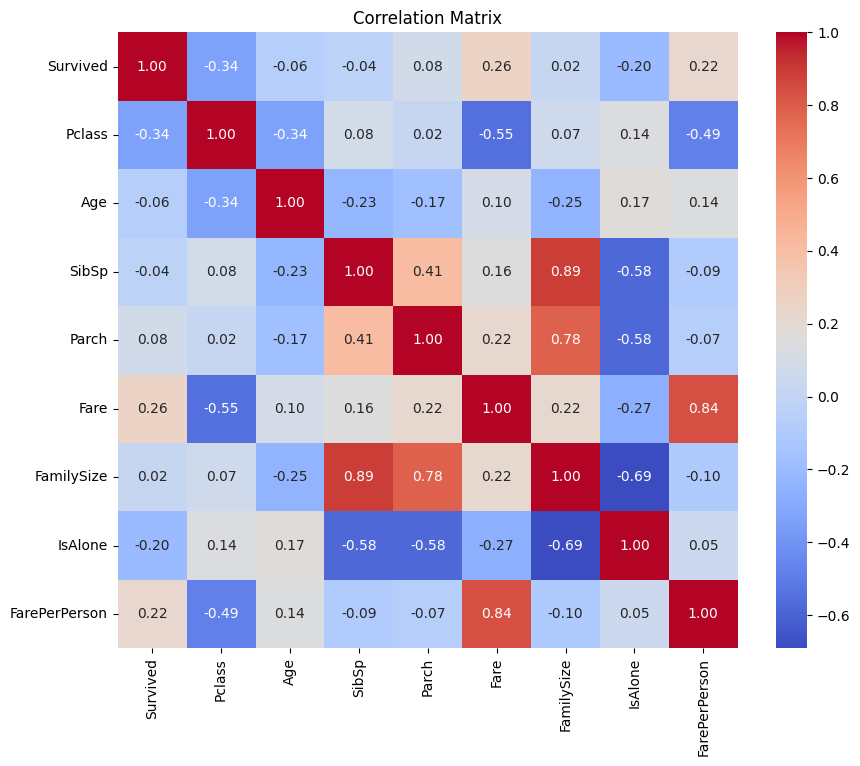

In [31]:
# Correlation matrix
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Used Correlation Analysis to identify redundant features.

Next...Random Forest Feature Importance
   Tree-based models rank features based on their predictive power.

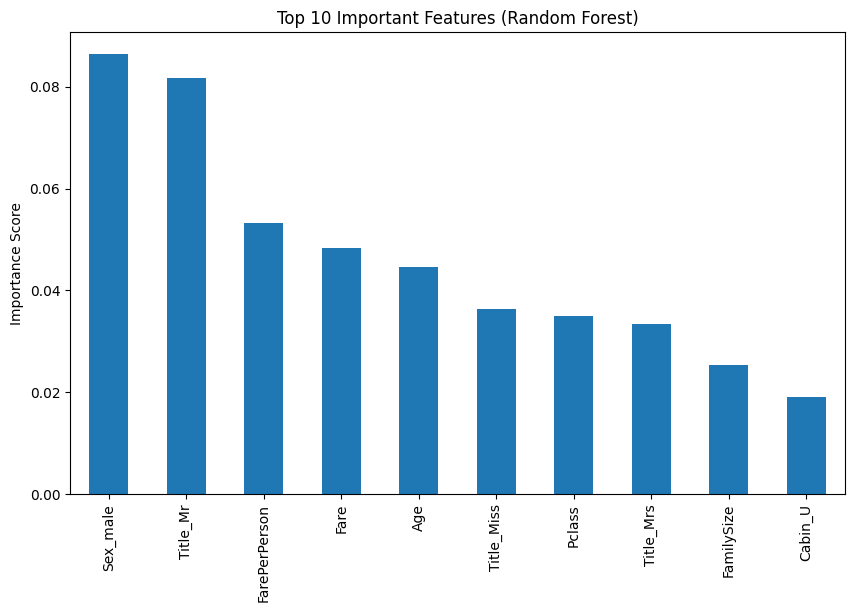

In [36]:
#preparing the dataset for Random forest feature importance
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#converting categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

#separating features from target
X = df_encoded.drop("Survived", axis=1)
y = df_encoded["Survived"]

#train random forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

#getting feature importance
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

#plotting feature importance
plt.figure(figsize=(10,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features (Random Forest)")
plt.ylabel("Importance Score")
plt.show()

The graph shows that sex(males) had the highest chance of survival and also title mr which also refers to males. The cabin is however on a lower rank of inmportance. To confirm this lets have a plot for gender.

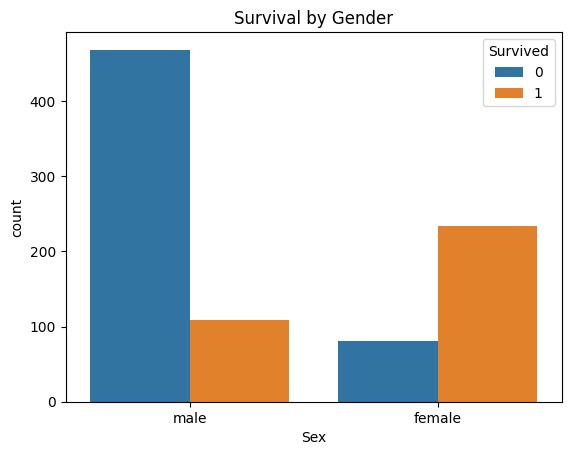

In [38]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

It is confirmed that mosr males survived while most females died. this leads to these questions
How many passengers survived?
How many died?

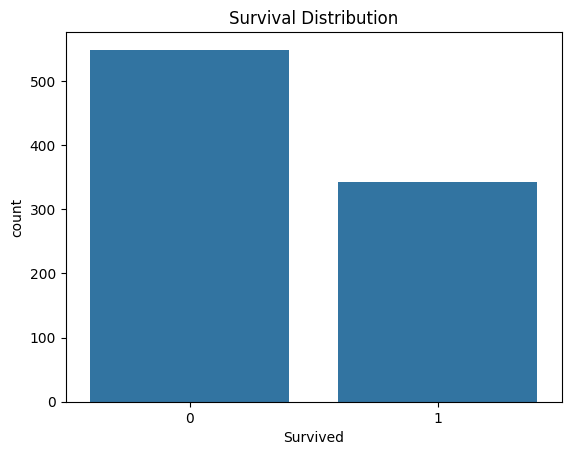

In [37]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.show()

According to the dataset, most people survived compared to those who dies, however the number of people who died is more than half of those who survived.

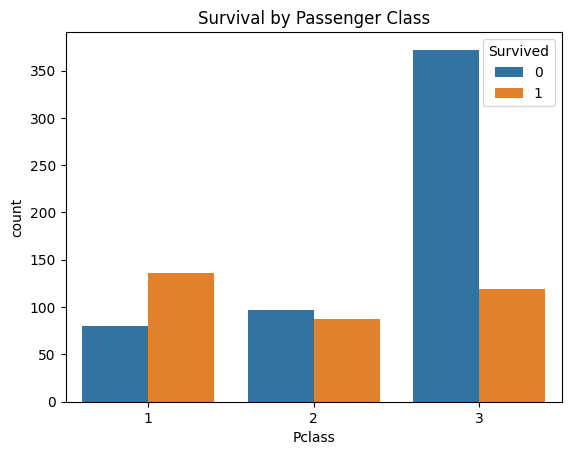

In [39]:
#survival by passenger class
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Survival by Passenger Class")
plt.show()

Passegers in Pclass3 reported higher rates of survival by far. This shows a class inequity on the Titanic.

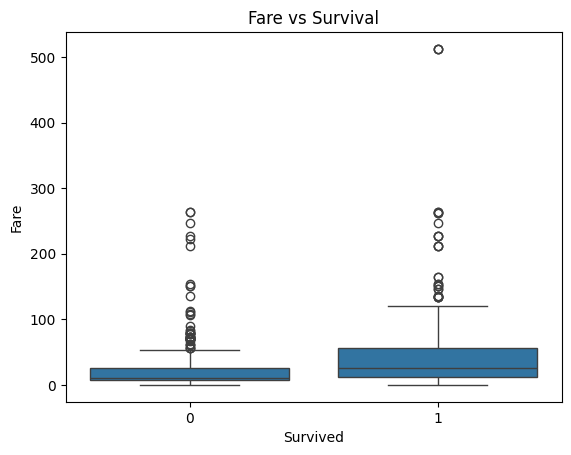

In [40]:
#fare vs survival
sns.boxplot(x="Survived", y="Fare", data=df)
plt.title("Fare vs Survival")
plt.show()

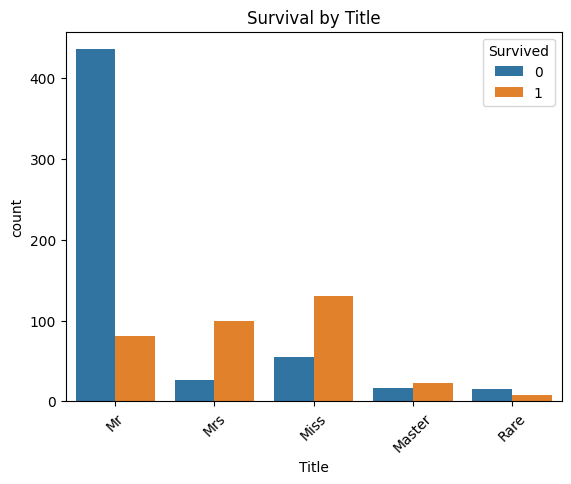

In [41]:
#survival vs title
sns.countplot(x="Title", hue="Survived", data=df)
plt.title("Survival by Title")
plt.xticks(rotation=45)
plt.show()

Those with title Mr showed higher rates of survival in the titanic while those with rare titles had lowe rates of survival. Those with titles Mrs and Miss reported more deaths than survivals.

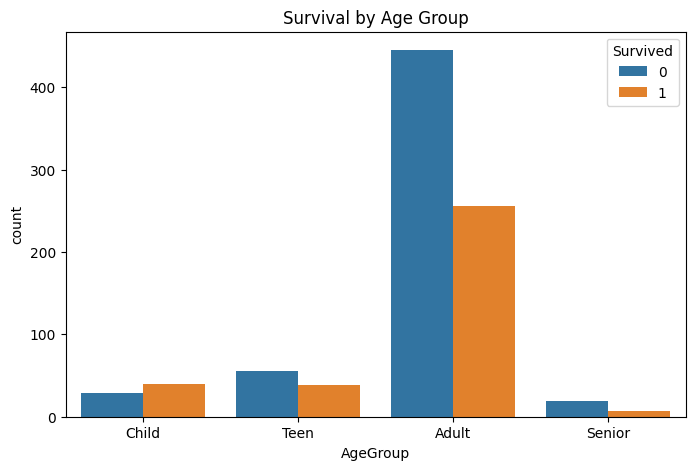

In [ ]:
#survival vs age groups
plt.figure(figsize=(8,5))
sns.countplot(x="AgeGroup", hue="Survived", data=df)
plt.title("Survival by Age Group")
plt.show()

Adults(20 - 59yrs) reported significantly higher chances of survival compared to the the other groups.

<Axes: >

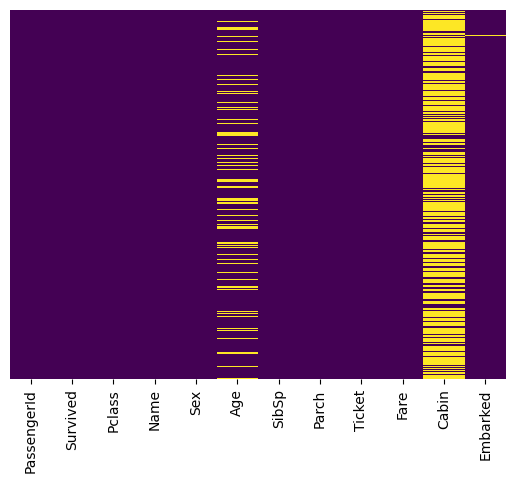

In [5]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

A Random Forest classifier was used to evaluate feature importance.

The most important predictors of survival were:

• Age – younger passengers had higher survival rates.
• Sex_male – females had significantly higher survival probability.
• Fare_Per_Person – higher ticket cost often corresponded to better survival chances.
• Pclass – passengers in first class had better survival rates.
• Titles (Mr, Miss, Mrs) – extracted from names, capturing gender and social roles.
• Family_Size – passengers traveling with family had slightly different survival outcomes.

These results align with historical accounts of the Titanic disaster where evacuation prioritized women and children.